In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
solar_data =pd.read_csv('../data/raw/Solar.csv')

In [3]:
solar_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       8760 non-null   object 
 1   hour       8760 non-null   int64  
 2   dc_output  8760 non-null   float64
 3   ac_output  8760 non-null   float64
dtypes: float64(2), int64(1), object(1)
memory usage: 273.9+ KB


In [4]:
solar_data.describe()

,hour,dc_output,ac_output
count,8760.000000,8760.000000,8760.00000
mean,11.500000,545.548757,520.38881
std,6.922582,892.183776,859.27953
min,0.000000,0.000000,0.00000
25%,5.750000,0.000000,0.00000
50%,11.500000,0.000000,0.00000
75%,17.250000,685.039750,648.45750
max,23.000000,3508.898000,3371.07300


In [5]:
solar_data.head()

,date,hour,dc_output,ac_output
0,000-01-01,0,0.0,0.0
1,000-01-01,1,0.0,0.0
2,000-01-01,2,0.0,0.0
3,000-01-01,3,0.0,0.0
4,000-01-01,4,0.0,0.0


In [10]:
data = pd.read_csv('../data/processed/energy_features_2019.csv')

In [13]:
data.date.values.shape

(8760,)

In [15]:
solar_data['date'] = data.date.values

In [16]:
solar_data

,date,hour,dc_output,ac_output
0,2019-01-01,0,0.0,0.0
1,2019-01-01,1,0.0,0.0
2,2019-01-01,2,0.0,0.0
3,2019-01-01,3,0.0,0.0
4,2019-01-01,4,0.0,0.0
...,...,...,...,...
8755,2019-12-31,19,0.0,0.0
8756,2019-12-31,20,0.0,0.0
8757,2019-12-31,21,0.0,0.0
8758,2019-12-31,22,0.0,0.0


In [17]:
solar_data.to_csv('../data/processed/solar_2019.csv', index = False)

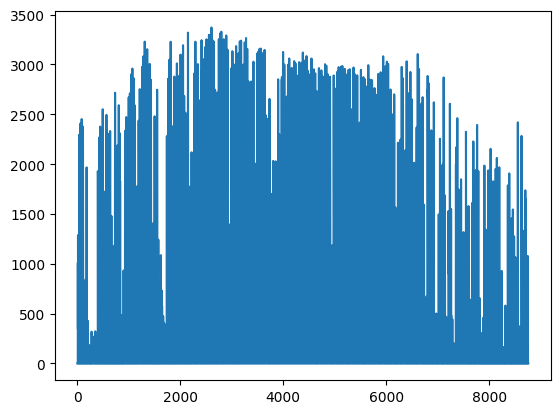

In [18]:
plt.plot(solar_data['ac_output'])

In [20]:
solar_data['date'] = pd.to_datetime(solar_data['date'])

In [23]:
avg_hourly = solar_data.groupby('hour')['ac_output'].mean()

In [25]:
type(avg_hourly)

pandas.core.series.Series

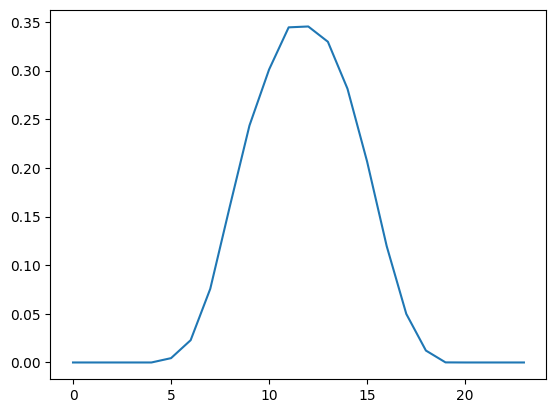

In [39]:
plt.plot(avg_hourly/5000)

In [40]:
df = pd.read_csv('../data/processed/energy_features_2019.csv')

In [42]:
df.columns

Index(['date', 'hour', 'avg_energy', 'temperature', 'humidity', 'pressure',
       'is_weekend', 'is_holiday'],
      dtype='object')

In [43]:
avg_hourly_demand = df.groupby('hour')['avg_energy'].mean()

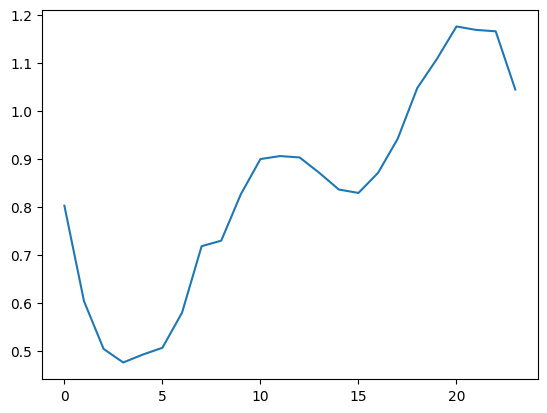

In [45]:
plt.plot(avg_hourly_demand)

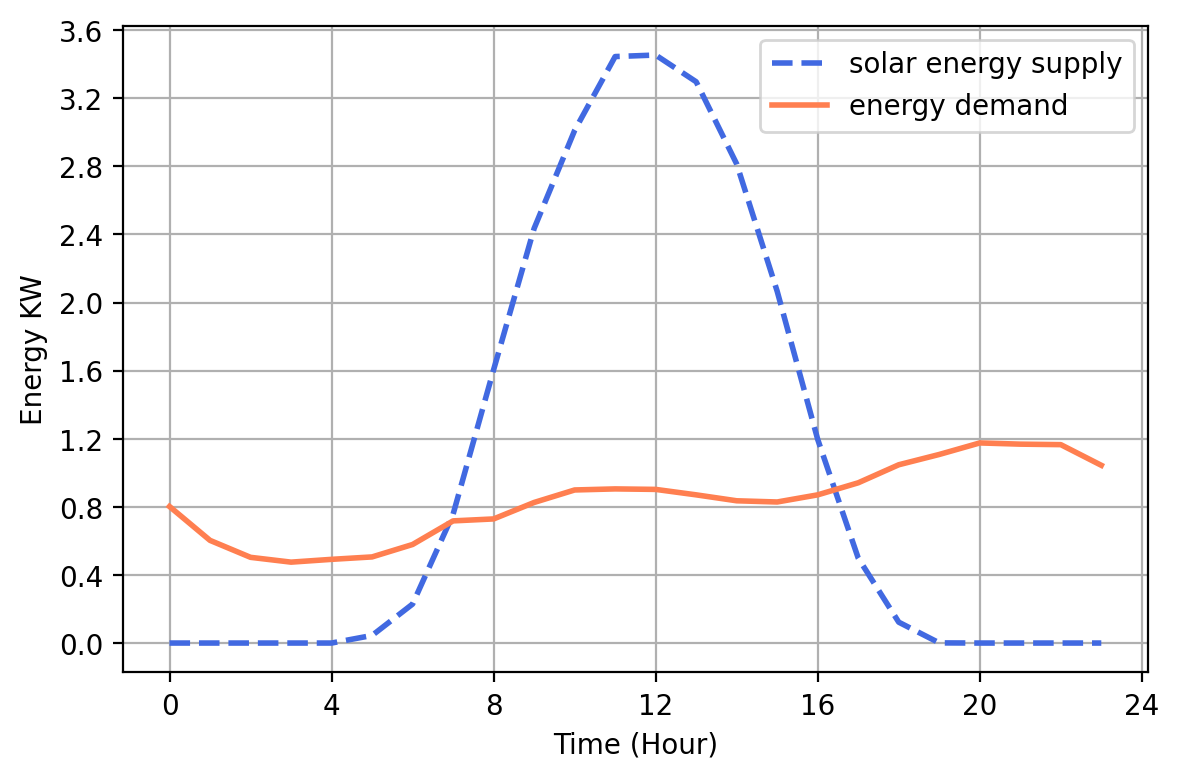

In [55]:
plt.figure(figsize=(6,4),dpi = 200)
plt.plot(avg_hourly/500, linewidth = 2, color = 'royalblue',linestyle = '--', label = 'solar energy supply')
plt.plot(avg_hourly_demand, linewidth = 2, color = 'coral', label = 'energy demand')
plt.grid()
plt.xticks(np.arange(0, 25, 4))
plt.yticks(np.arange(0, 4, 0.4))
plt.ylabel('Energy KW')
plt.xlabel('Time (Hour)')
plt.legend(loc = 1)
plt.tight_layout()
plt.savefig('../results/solar_demand_relation.png', dpi = 200)